# Compare Vabamorf with homonyms dataset


### Conclusive evaluation results for the models

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

| Model             | Accuracy | Precision | Recall | F1-score |
| ----------------- | -------: | --------: | -----: | -------: |
| Vabamorf (first)  |   83.30% |    82.93% | 83.30% |   83.01% |
| Vabamorf (random) |   83.31% |    82.94% | 83.31% |   83.02% |


### Imports


In [ ]:
print("Test")

Test


In [ ]:
# Imports
import sys
import pathlib

# Add the project's root directory to the Python path
sys.path.append(pathlib.Path("../").resolve().as_posix())

# Configurations
seed = 42
random_seed = seed  # Global variable to ensure reproducibility of random choices across function calls

# Paths
DATA_DIR = pathlib.Path("../data/")
ENC2017_ROOT = DATA_DIR / "enc2017"
UD_ET_EDT_ROOT = DATA_DIR / "ud_et_edt"
HOMONYMS_ROOT = DATA_DIR / "homonymous_word_forms"

ENC2017_DIRS = {
    "processed": ENC2017_ROOT / "processed",
    "raw": ENC2017_ROOT / "raw",
}

UD_ET_EDT_DIRS = {
    "processed": UD_ET_EDT_ROOT / "processed",
    "raw": UD_ET_EDT_ROOT / "raw",
}

HOMONYMS_DIRS = {
    "processed": HOMONYMS_ROOT / "processed",
    "annotations": HOMONYMS_ROOT / "annotations",
}

OUTPUT_DIR = pathlib.Path("../outputs/")
PLOTS_DIR = OUTPUT_DIR / "plots"
HOMONYMS_PLOTS_DIR = PLOTS_DIR / "homonyms"

MODEL_DIR = pathlib.Path("../models/")

In [ ]:
import os
import evaluate
import re
import random
import math
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any, Tuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from scripts.notebooks.NotebookFunctions import (
    _extract_prediction_from_layer,
    annotate_sentences_with_model,
    display_metrics_and_classification_report,
    plot_confusion_matrices,
    plot_true_vs_pred_by_inflection,
    display_examples,
    create_lenient_labels_and_split_counts_and_cases,
)

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
poseval = evaluate.load("evaluate-metric/poseval", module_type="metric")


def custom_metrics(preds, labels):

    # Evaluate using poseval
    result = poseval.compute(predictions=preds, references=labels, zero_division=0)

    return result

<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [ ]:
overall_df = pd.read_parquet(
    "../data/homonymous_word_forms/processed/homonyms_overall_updated_sentences.parquet"
)

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",[sg g],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [ ]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
)

display(
    overall_df.groupby(["inflection_type", "label"])
    .size()
    .reset_index()
    .sort_values(by="inflection_type")
)

,inflection_type,label,0
0,1,"(sg g,)",1232
1,1,"(sg n,)",764
2,16,"(sg g,)",1080
3,16,"(sg n,)",890
4,17,"(sg g,)",524
5,17,"(sg n,)",791
6,17,"(sg p,)",609
7,19,"(adt,)",94
8,19,"(sg g,)",1621
9,19,"(sg p,)",281


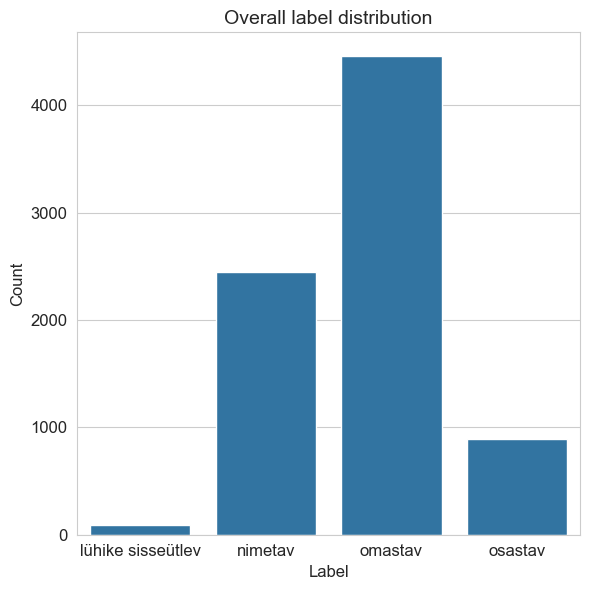

INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Admin\AppData\Local\Temp\ipykernel_32032\3500709682.py:38: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(


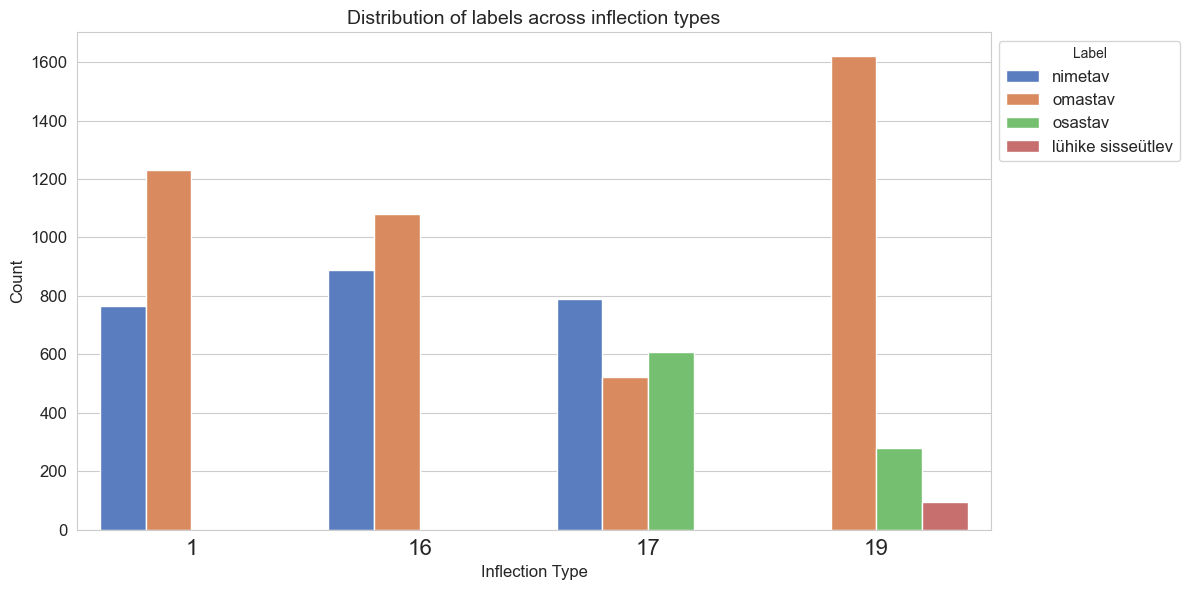

In [ ]:
overall_df["label_str"] = overall_df["label"].apply(lambda x: x[0])

# Rename the labels for better readability in plots
label_mapping = {
    "sg n": "nimetav",
    "sg g": "omastav",
    "sg p": "osastav",
    "adt": "lühike sisseütlev",
}
overall_df["label_str"] = (
    overall_df["label_str"].map(label_mapping).fillna(overall_df["label_str"])
)

# Plot label distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
sns.countplot(
    data=overall_df,
    x="label_str",
    order=sorted(overall_df["label_str"].dropna().unique()),
)
plt.title("Overall label distribution", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "overall_label_distribution.png"),
    dpi=300,
)
plt.show()

# Plot label distribution across inflection types
sns.set_style("whitegrid")
palette = sns.color_palette("muted")
plt.figure(figsize=(12, 6))
sns.countplot(
    data=overall_df,
    x="inflection_type",
    hue="label_str",
    palette=palette,
    order=sorted(overall_df["inflection_type"].dropna().unique()),
)
plt.title("Distribution of labels across inflection types", fontsize=14)
plt.xlabel("Inflection Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.legend(title="Label", bbox_to_anchor=(1, 1), loc="upper left", fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "label_distribution_by_inflection_type.png"),
    dpi=300,
)
plt.show()

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='tulemused_vaiksemal_valimil'></a>


### Comparison of all the models on the sample of 200 homonym sentences (label and inflection type pairs each with 20 sentences)


In [122]:
# Load original dataframe
overall_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_overall_sentences.parquet"
)

# Load results dataframes
df_vm = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_Vabamorf.csv",
    index_col=False,
)

df_bv1 = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V1.csv",
    index_col=False,
)

df_bv2 = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V2.csv",
    index_col=False,
)

df_bv2_full = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V2_homonym_full.csv",
    index_col=False,
)

# df_bv2_50 = pd.read_csv(
#     HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V2_homonym_50.csv",
#     index_col=False,
# )

mlm_bert_results_df_25 = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_bert_mlm_predictions_25.parquet"
)

mlm_bert_results_df_100 = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_bert_mlm_predictions_100.parquet"
)

max_rows = 200
mlm_llm_results_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / f"homonyms_llm_mlm_predictions_v3_{max_rows}.parquet"
)

bert_llm_results_df = pd.read_json(
    HOMONYMS_DIRS["processed"] / f"genai_annotations_bert_mlm_{max_rows}.json"
)

In [123]:
# Count how many IDs match between mlm_llm_results_df and bert_llm_results_df to confirm they are based on the same subset of sentences
matching_ids = set(mlm_llm_results_df["id"]).intersection(
    set(bert_llm_results_df["id"])
)
print(
    f"Number of matching IDs between LLM MLM-to-morph results and BERT MLM-to-LLM-to-morph results: {len(matching_ids)}"
)

Number of matching IDs between LLM MLM-to-morph results and BERT MLM-to-LLM-to-morph results: 200


In [124]:
# Print column names for all dataframes to check for consistency
print("Column names in Vabamorf results dataframe:", df_vm.columns.tolist())
print("Column names in BertMorphTaggerV1 results dataframe:", df_bv1.columns.tolist())
print("Column names in BertMorphTaggerV2 results dataframe:", df_bv2.columns.tolist())
print(
    "Column names in BertMorphTaggerV2 full results dataframe:",
    df_bv2_full.columns.tolist(),
)
# print("Column names in BertMorphTaggerV2 homonym 50 results dataframe:", df_bv2_50.columns.tolist())
print(
    "Column names in BERT MLM results dataframe (25 candidates):",
    mlm_bert_results_df_25.columns.tolist(),
)
print(
    "Column names in BERT MLM results dataframe (100 candidates):",
    mlm_bert_results_df_100.columns.tolist(),
)
print("Column names in LLM MLM results dataframe:", mlm_llm_results_df.columns.tolist())
print(
    "Column names in BERT MLM-to-LLM-to-morph results dataframe:",
    bert_llm_results_df.columns.tolist(),
)


# Rename columns for consistency
mlm_bert_results_df_25 = mlm_bert_results_df_25.rename(
    columns={
        "row_index": "id",
        "predicted_best_label": "pred_label",
        "true_label": "true_label",
    }
)
mlm_bert_results_df_100 = mlm_bert_results_df_100.rename(
    columns={
        "row_index": "id",
        "predicted_best_label": "pred_label",
        "true_label": "true_label",
    }
)
bert_llm_results_df = bert_llm_results_df.rename(columns={"label": "true_label"})

Column names in Vabamorf results dataframe: ['sentence', 'word', 'true_label', 'pred_label', 'num', 'inflection_type']
Column names in BertMorphTaggerV1 results dataframe: ['sentence', 'word', 'true_label', 'pred_label', 'num', 'inflection_type']
Column names in BertMorphTaggerV2 results dataframe: ['sentence', 'word', 'true_label', 'pred_label', 'num', 'inflection_type']
Column names in BertMorphTaggerV2 full results dataframe: ['sentence', 'word', 'true_label', 'pred_label', 'num', 'inflection_type']
Column names in BERT MLM results dataframe (25 candidates): ['row_index', 'inflection_type', 'sentence', 'word', 'word_span', 'true_label', 'predicted_best_label', 'predicted_best_label_score', 'predicted_top_labels', 'label_scores', 'source']
Column names in BERT MLM results dataframe (100 candidates): ['row_index', 'inflection_type', 'sentence', 'word', 'word_span', 'true_label', 'predicted_best_label', 'predicted_best_label_score', 'predicted_top_labels', 'label_scores', 'source']
Col

In [125]:
# Add inflection type column from subset of original dataframe to results dataframes
# Create a new column in the MLM results dataframes to hold the inflection type
# We check whether the index in the overall dataframe matches with the column id in the results dataframes
# We have to ensure that the index and id are of the same type (both int or both str) for the merge to work correctly
overall_df["id"] = overall_df.index.astype(str)
df_vm["id"] = df_vm.index.astype(str)
df_bv1["id"] = df_bv1.index.astype(str)
df_bv2["id"] = df_bv2.index.astype(str)
df_bv2_full["id"] = df_bv2_full.index.astype(str)
# df_bv2_50["id"] = df_bv2_50.index.astype(str)
mlm_bert_results_df_25["id"] = mlm_bert_results_df_25["id"].astype(str)
mlm_bert_results_df_100["id"] = mlm_bert_results_df_100["id"].astype(str)
mlm_llm_results_df["id"] = mlm_llm_results_df["id"].astype(str)
bert_llm_results_df["id"] = bert_llm_results_df["id"].astype(str)
if "inflection_type" not in mlm_llm_results_df.columns:
    mlm_llm_results_df = mlm_llm_results_df.merge(
        overall_df[["id", "inflection_type"]],
        left_on="id",
        right_on="id",
        how="left",
    )

bert_llm_results_df["id"] = bert_llm_results_df["id"].astype(str)
if "inflection_type" not in bert_llm_results_df.columns:
    bert_llm_results_df = bert_llm_results_df.merge(
        overall_df[["id", "inflection_type"]],
        left_on="id",
        right_on="id",
        how="left",
    )

In [127]:
# Count samples in each label and inflection type group
label_inflection_counts = (
    bert_llm_results_df.groupby(["inflection_type", "true_label"])
    .size()
    .reset_index(name="count")
)
display(label_inflection_counts)
label_inflection_counts = (
    mlm_llm_results_df.groupby(["inflection_type", "true_label"])
    .size()
    .reset_index(name="count")
)
display(label_inflection_counts)

,inflection_type,true_label,count
0,1,sg g,20
1,1,sg n,20
2,16,sg g,20
3,16,sg n,20
4,17,sg g,20
5,17,sg n,20
6,17,sg p,20
7,19,adt,20
8,19,sg g,20
9,19,sg p,20


,inflection_type,true_label,count
0,1,sg g,20
1,1,sg n,20
2,16,sg g,20
3,16,sg n,20
4,17,sg g,20
5,17,sg n,20
6,17,sg p,20
7,19,adt,20
8,19,sg g,20
9,19,sg p,20


In [128]:
# Filter out only the rows in the original results that correspond to the ids in the BERT MLM-to-LLM-to-morph results dataframe
bert_llm_ids = bert_llm_results_df["id"].unique()
df_vm_subset = df_vm[df_vm["id"].isin(bert_llm_ids)]
df_bv1_subset = df_bv1[df_bv1["id"].isin(bert_llm_ids)]
df_bv2_subset = df_bv2[df_bv2["id"].isin(bert_llm_ids)]
df_bv2_full_subset = df_bv2_full[df_bv2_full["id"].isin(bert_llm_ids)]
# df_bv2_50_subset = df_bv2_50[df_bv2_50["id"].isin(bert_llm_ids)]
mlm_bert_results_df_100_subset = mlm_bert_results_df_100[
    mlm_bert_results_df_100["id"].isin(bert_llm_ids)
]
mlm_llm_results_df_subset = mlm_llm_results_df[
    mlm_llm_results_df["id"].isin(bert_llm_ids)
]

# Check lengths of subsets to ensure they match the number of rows in the LLM results
print(
    len(df_vm_subset),
    "rows in Vabamorf results corresponding to LLM homonyms subset",
)
print(
    len(df_bv1_subset),
    "rows in BertMorphTaggerV1 results corresponding to LLM homonyms subset",
)
print(
    len(df_bv2_subset),
    "rows in BertMorphTaggerV2 results corresponding to LLM homonyms subset",
)
print(
    len(df_bv2_full_subset),
    "rows in BertMorphTaggerV2_full results corresponding to LLM homonyms subset",
)
# print(
#     len(df_bv2_50_subset),
#     "rows in BertMorphTaggerV2_50 results corresponding to LLM homonyms subset",
# )
print(
    len(mlm_bert_results_df_100_subset),
    "rows in Bert MLM results (100 candidates) corresponding to LLM homonyms subset",
)
print(
    len(bert_llm_results_df),
    "rows in Bert MLM-to-LLM-to-morph results corresponding to LLM homonyms subset",
)
print(
    len(mlm_llm_results_df_subset),
    "rows in LLM MLM results corresponding to LLM homonyms subset",
)

200 rows in Vabamorf results corresponding to LLM homonyms subset
200 rows in BertMorphTaggerV1 results corresponding to LLM homonyms subset
200 rows in BertMorphTaggerV2 results corresponding to LLM homonyms subset
200 rows in BertMorphTaggerV2_full results corresponding to LLM homonyms subset
200 rows in Bert MLM results (100 candidates) corresponding to LLM homonyms subset
200 rows in Bert MLM-to-LLM-to-morph results corresponding to LLM homonyms subset
200 rows in LLM MLM results corresponding to LLM homonyms subset


In [129]:
print("Vabamorf results:")
display_metrics_and_classification_report(
    results_df=df_vm_subset,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

print("BertMorphTaggerV1 results:")
display_metrics_and_classification_report(
    results_df=df_bv1_subset,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

print("BertMorphTaggerV2 results:")
display_metrics_and_classification_report(
    results_df=df_bv2_subset,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

print("BertMorphTaggerV2_homonym_full results:")
display_metrics_and_classification_report(
    results_df=df_bv2_full_subset,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

# print("BertMorphTaggerV2_homonym_50 results:")
# display_metrics_and_classification_report(
#     results_df=df_bv2_50_subset,
#     pred_col="pred_label",
#     true_col="true_label",
#     show_metrics=True,
#     show_classification_report=False,
# )

print("Bert MLM results (100 candidates, LLM subset) on homonyms dataset:")
display_metrics_and_classification_report(
    results_df=mlm_bert_results_df_100_subset,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

print("LLM MLM results on homonyms dataset:")
display_metrics_and_classification_report(
    results_df=mlm_llm_results_df_subset,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

print("BERT MLM-to-LLM-to-morph results on homonyms dataset:")
display_metrics_and_classification_report(
    results_df=bert_llm_results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

Vabamorf results:
Overall results
Accuracy:  75.00%
Precision: 77.63%
Recall:    75.00%
F1-score:  73.63%
BertMorphTaggerV1 results:
Overall results
Accuracy:  84.00%
Precision: 86.17%
Recall:    84.00%
F1-score:  83.35%
BertMorphTaggerV2 results:
Overall results
Accuracy:  93.50%
Precision: 95.17%
Recall:    93.50%
F1-score:  94.12%
BertMorphTaggerV2_homonym_full results:
Overall results
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1-score:  100.00%
Bert MLM results (100 candidates, LLM subset) on homonyms dataset:
Overall results
Accuracy:  69.00%
Precision: 81.19%
Recall:    69.00%
F1-score:  72.74%
LLM MLM results on homonyms dataset:
Overall results
Accuracy:  75.00%
Precision: 85.92%
Recall:    75.00%
F1-score:  79.25%
BERT MLM-to-LLM-to-morph results on homonyms dataset:
Overall results
Accuracy:  74.50%
Precision: 84.91%
Recall:    74.50%
F1-score:  78.05%


In [130]:
# Analyse mispredictions for BERT MLM, LLM MLM and BERT MLM-to-LLM-to-morph
mlm_bert_results_df_100_subset["correct"] = (
    mlm_bert_results_df_100_subset["pred_label"]
    == mlm_bert_results_df_100_subset["true_label"]
)

mlm_llm_results_df_subset["correct"] = (
    mlm_llm_results_df_subset["pred_label"] == mlm_llm_results_df_subset["true_label"]
)

bert_llm_results_df["correct"] = (
    bert_llm_results_df["pred_label"] == bert_llm_results_df["true_label"]
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_28640\2613695344.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mlm_bert_results_df_100_subset["correct"] = (


In [131]:
# Get groups of inflection type and label combinations
grouped_bert = mlm_bert_results_df_100_subset.groupby(["inflection_type", "true_label"])
grouped_llm = mlm_llm_results_df_subset.groupby(["inflection_type", "true_label"])
grouped_bert_llm = bert_llm_results_df.groupby(["inflection_type", "true_label"])

# Count total samples and mispredictions for each group
bert_total_and_mispred = (
    grouped_bert["correct"]
    .agg(total_samples="size", mispredictions=lambda x: (~x).sum())
    .reset_index()
)

llm_total_and_mispred = (
    grouped_llm["correct"]
    .agg(total_samples="size", mispredictions=lambda x: (~x).sum())
    .reset_index()
)

bert_llm_total_and_mispred = (
    grouped_bert_llm["correct"]
    .agg(total_samples="size", mispredictions=lambda x: (~x).sum())
    .reset_index()
)

In [132]:
# Print out the count of samples for each group and mispredictions for that group
print("BERT MLM mispredictions by inflection type and true label:")
print(bert_total_and_mispred)
print()
print("LLM MLM mispredictions by inflection type and true label:")
print(llm_total_and_mispred)
print("BERT MLM-to-LLM-to-morph mispredictions by inflection type and true label:")
print(bert_llm_total_and_mispred)

BERT MLM mispredictions by inflection type and true label:
   inflection_type true_label  total_samples  mispredictions
0                1       sg g             20               5
1                1       sg n             20               6
2               16       sg g             20               1
3               16       sg n             20               2
4               17       sg g             20               5
5               17       sg n             20               5
6               17       sg p             20              11
7               19        adt             20              14
8               19       sg g             20               4
9               19       sg p             20               9

LLM MLM mispredictions by inflection type and true label:
   inflection_type true_label  total_samples  mispredictions
0                1       sg g             20               2
1                1       sg n             20               4
2               16       sg 

In [135]:
display(filtered_df.columns)

Index(['id', 'inflection_type', 'sentence', 'word', 'word_span', 'true_label',
       'pred_label', 'predicted_best_label_score', 'predicted_top_labels',
       'label_scores', 'source', 'correct'],
      dtype='object')

In [143]:
display(filtered_df.head())

,id,candidates,pred_label,true_label,predicted_form_distribution,source_sentence,target_word,word_span,inflection_type,correct
1,6741,"[aktiivsed, asjast, kampaaniast, algatusest, tegevusest, projektist, sündmusest, ettevõtmisest, liikumisest, uudisest]",sg el,sg p,"{'': None, '?': None, 'adt': None, 'nud': None, 'pl ab': None, 'pl all': None, 'pl el': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': 0.1, 'pl p': None, 's': None, 'sg all': None, 'sg el': 0.8999999999999999, 'sg g': None, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': None, 'sg p': None, 'sg ter': None, 'sg tr': None, 'tud': None}","""Tahame, et sellest saaksid osa võimalikult paljud väiksed spordi- ja loomasõbrad,"" ütles Rüütmann.",osa,"[28, 31]",17,False
3,6544,"[kapitali, vara, ressursse, vahendeid, investeeringuid, tulu, sääste, finantse, varandust, tööjõudu]",pl p,sg p,"{'': None, '?': None, 'adt': None, 'nud': None, 'pl ab': None, 'pl all': None, 'pl el': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': 0.5, 's': None, 'sg all': None, 'sg el': None, 'sg g': 0.2, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': None, 'sg p': 0.30000000000000004, 'sg ter': None, 'sg tr': None, 'tud': None}","Preatoni ja teiste välisinvestorite seisukohast vaadatuna ei ole turismiäri ajamine Eestis tõesti eriti atraktiivne, sest maailmakodanikena saavad nad paigutada oma raha just sinna maailmanurka ja tegevusalasse, kus riski ja tulu vahekord on parajasti kõige soodsam.",raha,"[165, 169]",17,False
7,5587,"[Aleksei, Dmitri, Sergei, Andrei, Nikolai, Jevgeni, Valeri, Viktor, Vladimir, Mihhail]",sg n,sg g,"{'': None, '?': None, 'adt': None, 'nud': None, 'pl ab': None, 'pl all': None, 'pl el': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 's': None, 'sg all': None, 'sg el': None, 'sg g': 0.4, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': 0.6, 'sg p': None, 'sg ter': None, 'sg tr': None, 'tud': None}","Kell 21. 30 leidis politseipatrull Vilde teelt trepikojast 36-aastase Vitali surnukeha, keda oli löödud noaga südamesse.",Vitali,"[70, 76]",16,False
12,884,"[Ameerika, Austraalia, Uus-Meremaa, Brasiilia, Argentina, Mehhiko, Kolumbia, Tšiili, Uruguay, Paraguay]",sg n,sg g,"{'': None, '?': None, 'adt': None, 'nud': None, 'pl ab': None, 'pl all': None, 'pl el': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 's': None, 'sg all': None, 'sg el': None, 'sg g': 0.2, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': 0.7999999999999999, 'sg p': None, 'sg ter': None, 'sg tr': None, 'tud': None}",Kanada rajasid inglastest ja prantslastest väljarändajad.,Kanada,"[0, 6]",1,False
23,667,"[välismaised, kogenud, juhtivad, tunnustatud, kohalikud, aktiivsed, pädevad, ühenduse, tegevad, vastutavad]",pl n,sg g,"{'': 0.05, '?': None, 'adt': None, 'nud': 0.025, 'pl ab': None, 'pl all': None, 'pl el': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': 0.7499999999999999, 'pl p': None, 's': None, 'sg all': None, 'sg el': None, 'sg g': 0.1, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': 0.05, 'sg p': None, 'sg ter': None, 'sg tr': None, 'tud': 0.025}","Tööandjad peaksid töö nii korraldama, et inimesed ei oleks sunnitud tööasju telefonitsi ajama, kui nad autoga ringi sõidavad, soovitavad Euroopa töötervishoiuspetsialistid.",Euroopa,"[137, 144]",1,False


In [145]:
# filtered_df = mlm_bert_results_df_100_subset[~mlm_bert_results_df_100_subset["correct"]]
# filtered_df = filtered_df[
#     (filtered_df["true_label"] == "adt") & (filtered_df["pred_label"] != "adt")
# ]
# display_examples(
#     filtered_df,
#     num_examples=5,
#     display_or_print="print",
#     list_of_columns_to_show=[
#         "id",
#         "inflection_type",
#         "sentence",
#         "word",
#         "true_label",
#         "pred_label",
#         "predicted_best_label_score",
#         "predicted_top_labels",
#     ],
# )
filtered_df = mlm_llm_results_df_subset[~mlm_llm_results_df_subset["correct"]]
filtered_df = filtered_df[
    (filtered_df["true_label"] == "adt") & (filtered_df["pred_label"] != "adt")
]
display_examples(
    filtered_df,
    num_examples=5,
    display_or_print="print",
    list_of_columns_to_show=[
        "id",
        "inflection_type",
        "source_sentence",
        "target_word",
        "candidates",
        "true_label",
        "pred_label",
        "predicted_form_distribution",
    ],
)

Example 1 (index 142):
  id: 3841
  inflection_type: 19
  source_sentence: "See etendus sobib vanasse anatoomikumi, sest hoone on sünge ja võimas," põhjendas draamajuht valikut.
  target_word: anatoomikumi
  candidates: ['haiglasse' 'koolimajja' 'kirikusse' 'vanglasse' 'lossi' 'teatrisse'
 'muuseumisse' 'tornidesse' 'keldrisse' 'hoidlasse']
  true_label: adt
  pred_label: sg ill
  predicted_form_distribution: {'': None, '?': None, 'adt': 0.25, 'nud': None, 'pl ab': None, 'pl all': None, 'pl el': None, 'pl g': None, 'pl ill': 0.1, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 's': None, 'sg all': None, 'sg el': None, 'sg g': None, 'sg ill': 0.65, 'sg in': None, 'sg kom': None, 'sg n': None, 'sg p': None, 'sg ter': None, 'sg tr': None, 'tud': None}
----------------------------------------
Example 2 (index 144):
  id: 7088
  inflection_type: 19
  source_sentence: Või läheks hiina restorani sööma, härra Allikmaa?
  target_word: restorani
  candidates: ['söögikohta' 'kohvikusse

## END
